In [ ]:
# HyperOpt 를 찾기 위한 기본 루틴 정리본 ,
# 본 파일을 save_as 이니셜_1.모델축약어_FindHO.ipynb 로 저장하세요~ ex) lkj_1.XGB_FindHO.ipynb

In [2]:
import sys
import os

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
import pandas as pd
import numpy  as np
from scipy.special import logit
import time
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import math

from xgboost import XGBClassifier, plot_importance
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix, recall_score, precision_score
from sklearn.datasets import make_classification
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import seaborn as sns

import importlib
from utils import preprocessing
importlib.reload(preprocessing) # 모듈 reload
# importlib.reload(user_utils)

import utils.preprocessing as pp
import utils.user_utils    as uu
import utils.model_utils   as mu
import utils.evaluation    as ev
import utils.modeling      as mo
import utils.data_sampling as ds

# train = pd.read_csv("../data/train.csv")
# test  = pd.read_csv("../data/test.csv")

In [4]:
# 결과받을 딕셔너리
results = {}
team_rs = 23 # 우리팀 random_state

In [5]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [6]:
# 2. Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')

In [7]:
# 3. 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [8]:
# 4.1 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

In [9]:
# 5.1 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [10]:
# 4.2 Over Sampling 하는 경우
X_over, y_over = ds.oversampling_smote(X_train, y_train)

✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)


In [11]:
# 5.2 Over Sampling한 경우 학습/검증 데이터 분리
X_tr_over, X_val_over, y_tr_over, y_val_over = pp.data_split(X_over, y_over, size=0.4)

In [ ]:
#6 하이퍼파라미터
tuner = uu.HyperOptTuner(max_evals=100, random_state=23)

# =========================
# LinearRegression HyperOpt
# =========================

# 1) LinearRegression용 search space
#    - 튜닝 가능한 건 거의 없어서 fit_intercept / positive만 사용
fit_options = [True, False]
pos_options = [False, True]

lin_search_space = {
    "fit_intercept": hp.choice("fit_intercept", list(range(len(fit_options)))),  # 0 or 1
    "positive":      hp.choice("positive",      list(range(len(pos_options)))),  # 0 or 1
}

def lin_objective(params):
    """
    LinearRegression HyperOpt 목적 함수.
    - 회귀 예측값을 0~1로 클리핑해서 '확률 비슷한 값'으로 간주
    - 검증셋에서 AUC(roc_auc_score)를 최대화하도록 -AUC를 loss로 반환
    """
    # 인덱스 → 실제 bool 값
    fit_intercept = fit_options[params["fit_intercept"]]
    positive      = pos_options[params["positive"]]

    model = LinearRegression(
        fit_intercept=fit_intercept,
        positive=positive,
    )

    # HyperOpt용 train/val: 이상치 cap만 된 상태의 X_tr, X_val 사용
    model.fit(X_tr, y_tr)

    # 연속값 예측
    y_val_cont = model.predict(X_val)

    # 0~1 범위로 클리핑 → 확률처럼 사용
    y_val_proba = np.clip(y_val_cont, 0, 1)

    # AUC 계산 (문제 생기면 loss 크게 줌)
    try:
        auc = roc_auc_score(y_val, y_val_proba)
    except ValueError:
        return {"loss": 1.0, "status": STATUS_OK}

    return {"loss": -auc, "status": STATUS_OK}


In [13]:
# 2) HyperOpt 실행
lin_trials = Trials()
best_lin_idx = fmin(
    fn=lin_objective,
    space=lin_search_space,
    algo=tpe.suggest,
    max_evals=50,                      # Logistic보다 가볍게
    trials=lin_trials,
    rstate=np.random.default_rng(team_rs),
)

# 3) 인덱스 → 실제 파라미터로 변환
best_lin_params = {
    "fit_intercept": fit_options[best_lin_idx["fit_intercept"]],
    "positive":      pos_options[best_lin_idx["positive"]],
}
print("\n[LinearRegression] Best Params:", best_lin_params)


100%|██████████| 50/50 [00:07<00:00,  7.03trial/s, best loss: -0.9422526442033441]

[LinearRegression] Best Params: {'fit_intercept': True, 'positive': True}


In [14]:
# =========================
# LinearRegression 최종 학습/저장/평가
# =========================

# 4) 최종 학습은 train/test 전체 기준 + StandardScaler 적용 후 진행
scaler_lin = StandardScaler()
X_train_scaled_lin = scaler_lin.fit_transform(X_train)
X_test_scaled_lin  = scaler_lin.transform(X_test)

final_lin = LinearRegression(**best_lin_params)

start_time = time.time()
final_lin.fit(X_train_scaled_lin, y_train)

# ✅ 모델 저장 (../models에 pkl)
mu.save_model(final_lin, "LiR_ho_best")

# 5) 예측: 연속값 → 0~1 클리핑 → 0.5 기준으로 이진 라벨
y_pred_cont = final_lin.predict(X_test_scaled_lin)
y_proba_lin = np.clip(y_pred_cont, 0, 1)
y_pred_lin  = (y_proba_lin >= 0.5).astype(int)

exec_time = time.time() - start_time

# 6) 분류 지표 계산 (AUC, 정확도, 정밀도, 재현율, F1)
auc_lin  = roc_auc_score(y_test, y_proba_lin)
acc_lin  = accuracy_score(y_test, y_pred_lin)
prec_lin = precision_score(y_test, y_pred_lin, zero_division=0)
rec_lin  = recall_score(y_test, y_pred_lin, zero_division=0)
f1_lin   = f1_score(y_test, y_pred_lin, zero_division=0)
cm_lin   = confusion_matrix(y_test, y_pred_lin)

print("\n[LinearRegression] 최종 성능")
print(f"AUC      : {auc_lin:.4f}")
print(f"Accuracy : {acc_lin:.4f}")
print(f"Precision: {prec_lin:.4f}")
print(f"Recall   : {rec_lin:.4f}")
print(f"F1       : {f1_lin:.4f}")
print("Confusion Matrix:")
print(cm_lin)

✓ 모델 저장 완료: ../models\LiR_ho_best.pkl
  파일 크기: 0.00 MB

[LinearRegression] 최종 성능
AUC      : 0.9358
Accuracy : 0.9983
Precision: 0.0000
Recall   : 0.0000
F1       : 0.0000
Confusion Matrix:
[[56864     0]
 [   98     0]]


In [15]:
# 7) 기존 유틸로 결과 txt 저장 (다른 모델과 동일 폴더/포맷)
uu.get_clf_eval(
    y_test,
    y_pred_lin,
    y_proba_lin,
    model_name="LiR_ho_best",
    exec_time=exec_time,
    HO_params=best_lin_params,
)

# 8) results 딕셔너리에 넣어서 그래프용으로도 사용
lin_result_dict = {
    "AUC": auc_lin,
    "정확도": acc_lin,
    "정밀도": prec_lin,
    "재현율": rec_lin,
    "F1": f1_lin,
}
results["LiR_ho_best"] = lin_result_dict

folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9358, '정확도': 0.9983, '정밀도': 0.0000, '재현율': 0.0000, 'F1': 0.0000 }
{'오차행렬':
[[56864     0]
 [   98     0]] }
실행 시간: 0.21999716758728027
하이퍼파라미터: {'fit_intercept': True, 'positive': True}


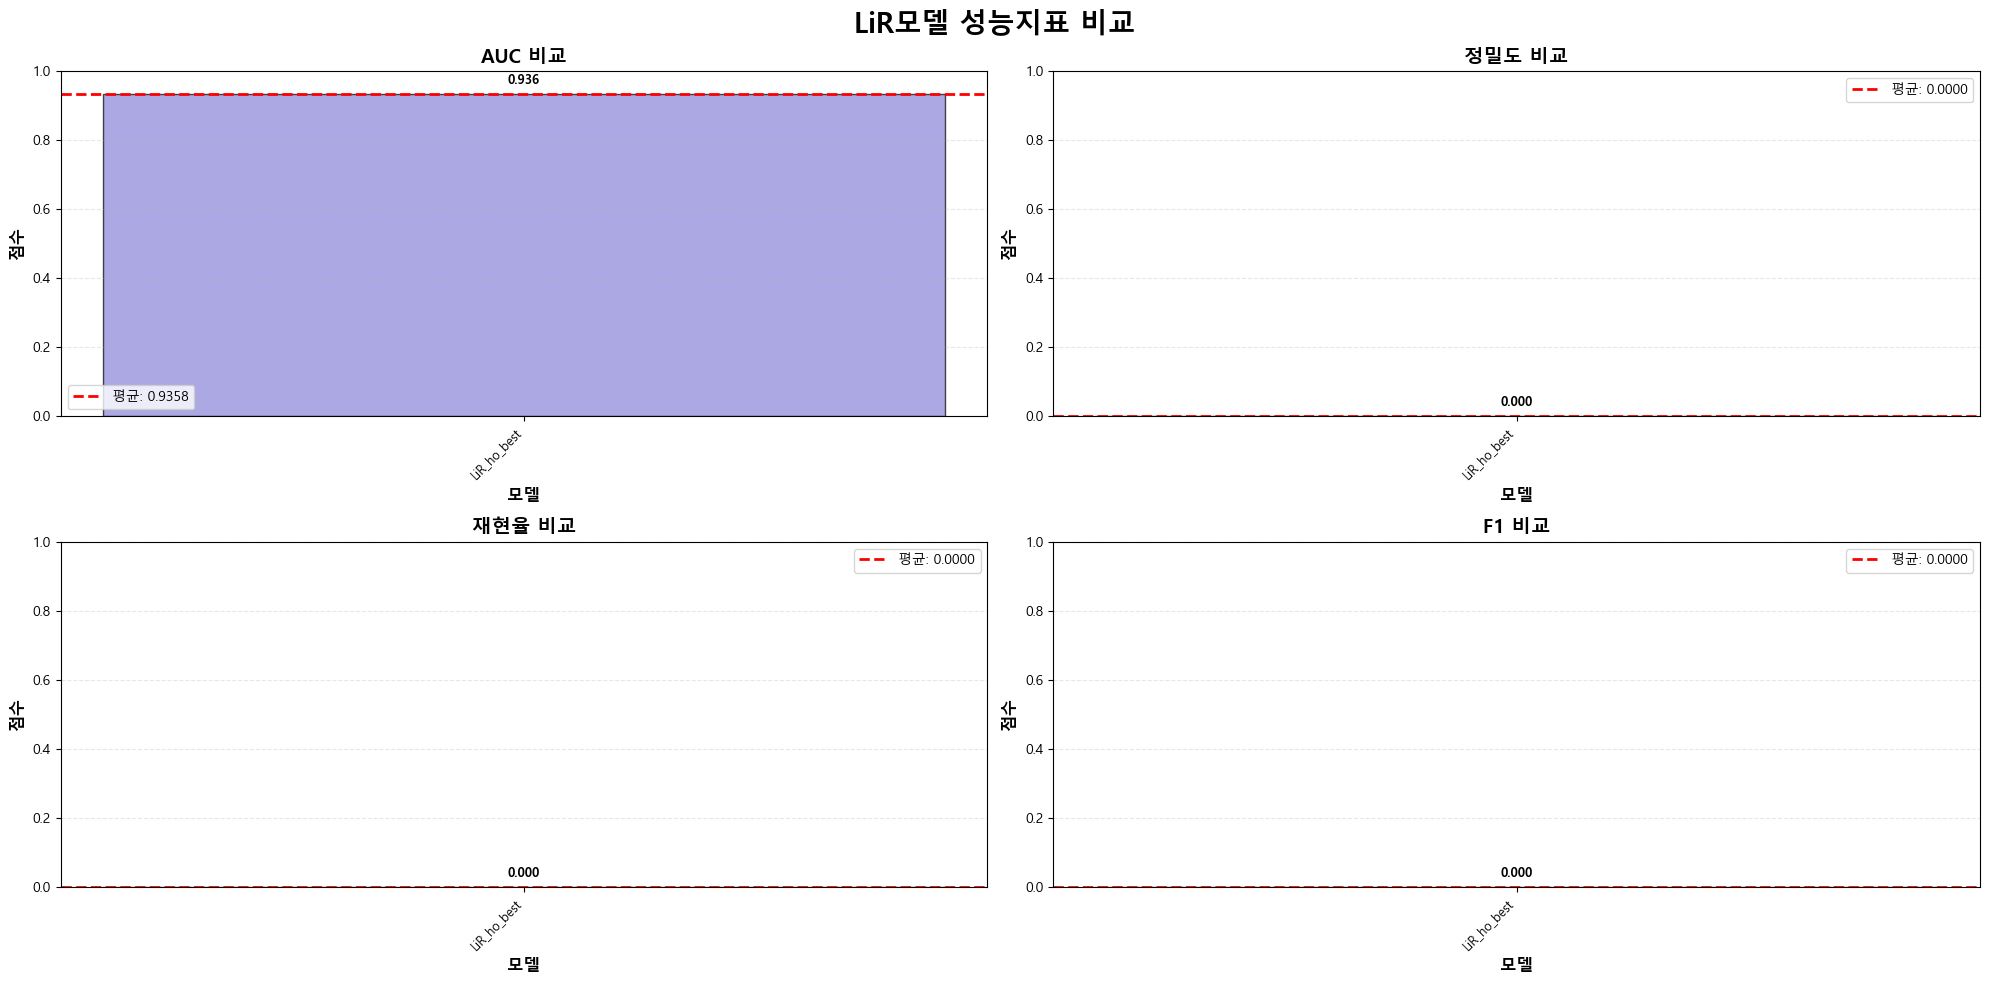


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9358 (LiR_ho_best)
  최저: 0.9358 (LiR_ho_best)
  평균: 0.9358
  표준편차: nan

[정밀도]
  최고: 0.0000 (LiR_ho_best)
  최저: 0.0000 (LiR_ho_best)
  평균: 0.0000
  표준편차: nan

[재현율]
  최고: 0.0000 (LiR_ho_best)
  최저: 0.0000 (LiR_ho_best)
  평균: 0.0000
  표준편차: nan

[F1]
  최고: 0.0000 (LiR_ho_best)
  최저: 0.0000 (LiR_ho_best)
  평균: 0.0000
  표준편차: nan


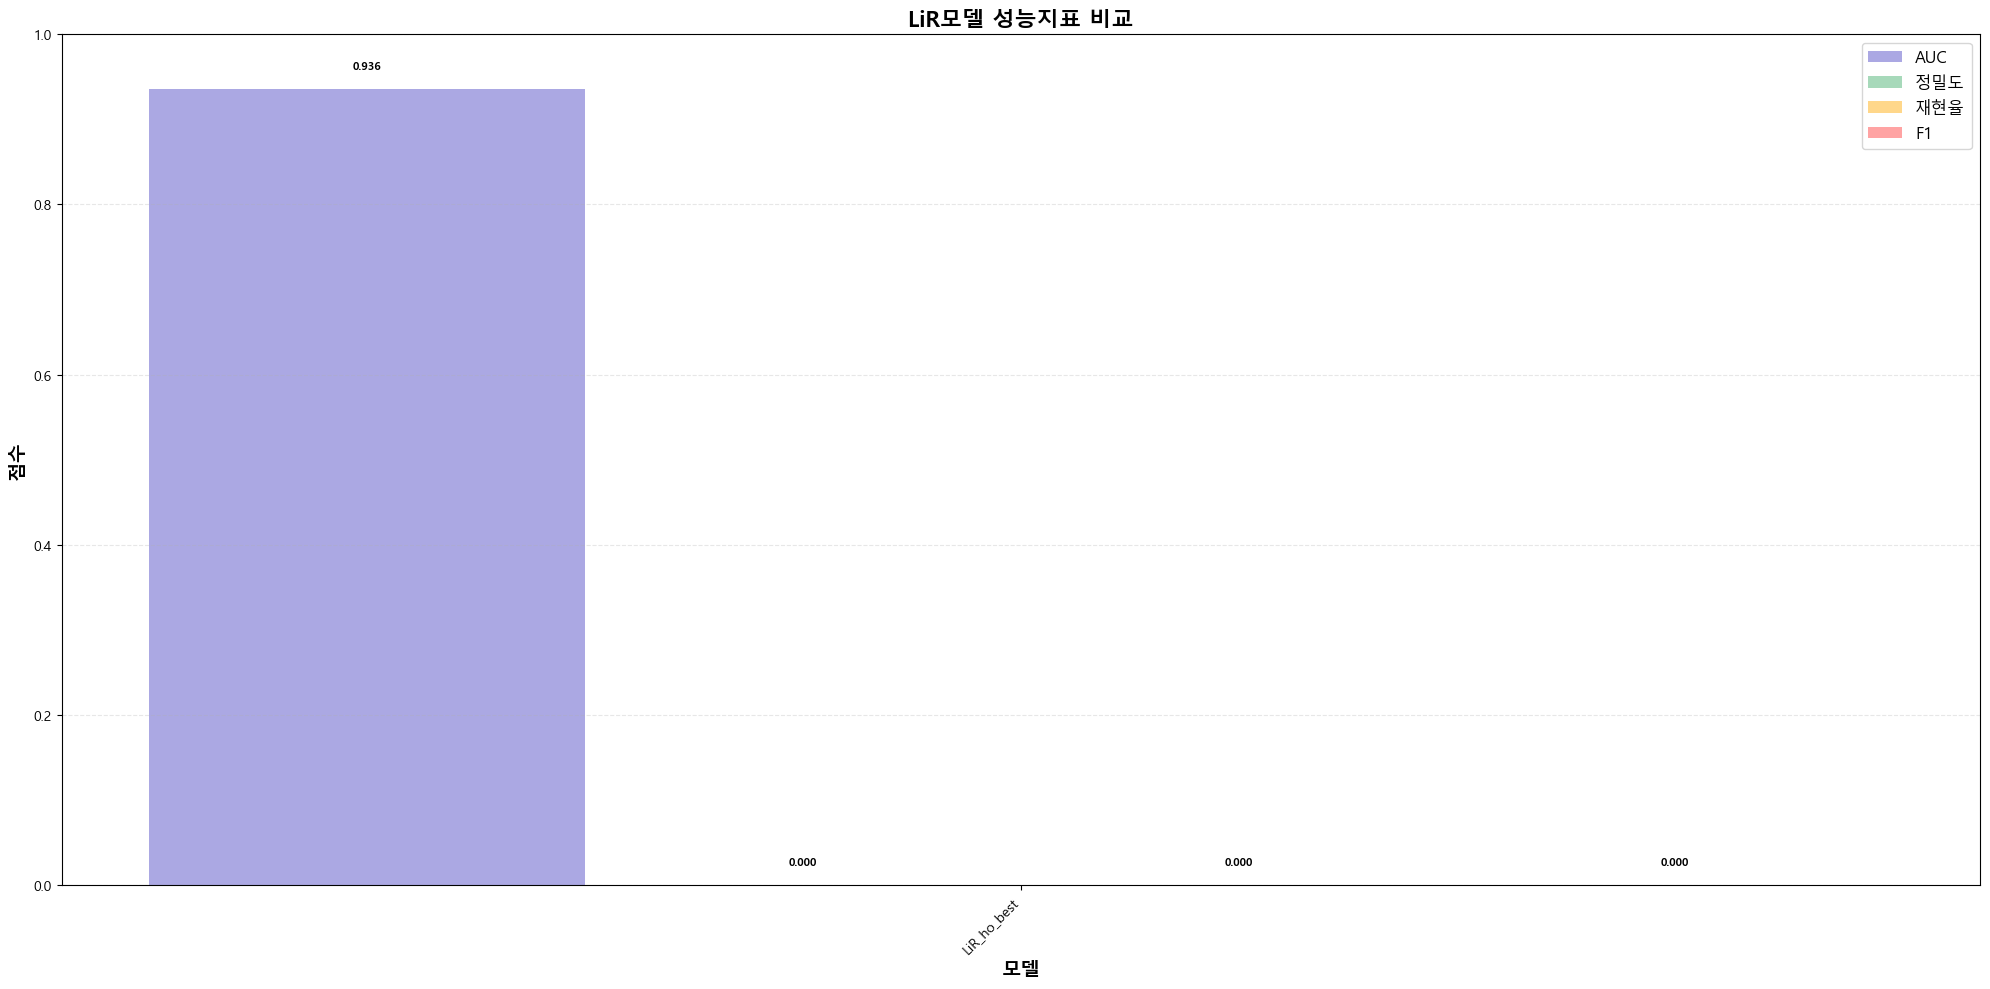


=== F1 Score 기준 상위 5개 모델 ===
                  AUC  정밀도  재현율   F1
LiR_ho_best  0.935754  0.0  0.0  0.0

=== AUC 기준 상위 5개 모델 ===
                  AUC  정밀도  재현율   F1
LiR_ho_best  0.935754  0.0  0.0  0.0

그래프가 저장되었습니다: ../images/LiR모델_성능지표_비교_2025_1130.png


In [16]:
# 7 시각화
mo.model_metrics_graph(results, 'LiR모델 성능지표 비교')

In [ ]:
# BestOpt 찾고 나서 스케일적용 버전 만들어서 모델링하기
# X_train_scaled, X_test_scaled, scaler = pp.scale_data(X_train, X_test)